<a href="https://colab.research.google.com/github/msolowes-star/Hackathon/blob/movie-recommendation/Hackathon_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MovieMatch AI: Personalized Movie Recommendation System

## Hackathon Project

### Objective
The goal of this project is to build a Python-based movie recommendation system that suggests movies based on user preferences and viewing history.

The project uses:
- Python programming
- Pandas and NumPy for data analysis
- SciPy for statistical analysis and user similarity
- K-means clustering to group similar users
- Matplotlib and Seaborn for data visualization

The recommendation system analyzes users' specific preferences, movie ratings, and viewing history to generate personalized movie suggestions.

Importing the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.cluster.vq import kmeans2

print("Libraries imported successfully!")

Libraries imported successfully!


Creating the movie dataset

## 1. Simulating Movie and User Data

I created a movie dataset containing movie titles, genres, directors, release years, and average ratings.

User profiles were also created with age, preferred genres, and viewing histories.

In [2]:
movies_data = [
    [1, "Inception", "Sci-Fi", "Christopher Nolan", 2010, 4.8],
    [2, "Interstellar", "Sci-Fi", "Christopher Nolan", 2014, 4.7],
    [3, "The Matrix", "Sci-Fi", "Lana and Lilly Wachowski", 1999, 4.7],
    [4, "The Dark Knight", "Action", "Christopher Nolan", 2008, 4.9],
    [5, "Avengers: Endgame", "Action", "Anthony and Joe Russo", 2019, 4.5],
    [6, "Mission Impossible", "Action", "Brian De Palma", 1996, 4.3],
    [7, "Gladiator", "Action", "Ridley Scott", 2000, 4.6],
    [8, "Titanic", "Drama", "James Cameron", 1997, 4.5],
    [9, "The Godfather", "Drama", "Francis Ford Coppola", 1972, 4.9],
    [10, "The Shawshank Redemption", "Drama", "Frank Darabont", 1994, 4.9],
    [11, "The Notebook", "Romance", "Nick Cassavetes", 2004, 4.2],
    [12, "La La Land", "Romance", "Damien Chazelle", 2016, 4.3],
    [13, "Crazy Rich Asians", "Romance", "Jon M. Chu", 2018, 4.1],
    [14, "Toy Story", "Animation", "John Lasseter", 1995, 4.6],
    [15, "Finding Nemo", "Animation", "Andrew Stanton", 2003, 4.5],
    [16, "Frozen", "Animation", "Chris Buck", 2013, 4.2],
    [17, "Jurassic Park", "Adventure", "Steven Spielberg", 1993, 4.6],
    [18, "Indiana Jones", "Adventure", "Steven Spielberg", 1981, 4.5],
    [19, "The Lord of the Rings", "Fantasy", "Peter Jackson", 2001, 4.9],
    [20, "Harry Potter", "Fantasy", "Chris Columbus", 2001, 4.7],
    [21, "The Silence of the Lambs", "Thriller", "Jonathan Demme", 1991, 4.6],
    [22, "Gone Girl", "Thriller", "David Fincher", 2014, 4.4],
    [23, "Shutter Island", "Thriller", "Martin Scorsese", 2010, 4.5],
    [24, "Spider-Man: No Way Home", "Action", "Jon Watts", 2021, 4.6]
]

movies_df = pd.DataFrame(
    movies_data,
    columns=["movie_id", "title", "genre", "director", "year", "average_rating"]
)

movies_df.head()

,movie_id,title,genre,director,year,average_rating
0,1,Inception,Sci-Fi,Christopher Nolan,2010,4.8
1,2,Interstellar,Sci-Fi,Christopher Nolan,2014,4.7
2,3,The Matrix,Sci-Fi,Lana and Lilly Wachowski,1999,4.7
3,4,The Dark Knight,Action,Christopher Nolan,2008,4.9
4,5,Avengers: Endgame,Action,Anthony and Joe Russo,2019,4.5


### User Profiles

Each user has:
- A name
- An age
- Preferred movie genres
- A viewing history containing movies watched and ratings

These profiles simulate the type of information a real streaming platform could use to personalize recommendations.

In [3]:
users = [
    {
        "name": "John",
        "age": 25,
        "preferences": ["Sci-Fi", "Action"],
        "watch_history": [
            {"movie": "Inception", "genre": "Sci-Fi", "director": "Christopher Nolan", "rating": 5},
            {"movie": "The Matrix", "genre": "Sci-Fi", "director": "Lana and Lilly Wachowski", "rating": 5},
            {"movie": "The Dark Knight", "genre": "Action", "director": "Christopher Nolan", "rating": 4},
            {"movie": "Gladiator", "genre": "Action", "director": "Ridley Scott", "rating": 4}
        ]
    },

    {
        "name": "Sarah",
        "age": 31,
        "preferences": ["Drama", "Romance"],
        "watch_history": [
            {"movie": "Titanic", "genre": "Drama", "director": "James Cameron", "rating": 5},
            {"movie": "The Notebook", "genre": "Romance", "director": "Nick Cassavetes", "rating": 4},
            {"movie": "La La Land", "genre": "Romance", "director": "Damien Chazelle", "rating": 5},
            {"movie": "The Godfather", "genre": "Drama", "director": "Francis Ford Coppola", "rating": 4}
        ]
    },

    {
        "name": "David",
        "age": 28,
        "preferences": ["Action", "Adventure"],
        "watch_history": [
            {"movie": "Gladiator", "genre": "Action", "director": "Ridley Scott", "rating": 5},
            {"movie": "Jurassic Park", "genre": "Adventure", "director": "Steven Spielberg", "rating": 5},
            {"movie": "Mission Impossible", "genre": "Action", "director": "Brian De Palma", "rating": 4},
            {"movie": "Indiana Jones", "genre": "Adventure", "director": "Steven Spielberg", "rating": 4}
        ]
    },

    {
        "name": "Rachel",
        "age": 35,
        "preferences": ["Drama", "Thriller"],
        "watch_history": [
            {"movie": "The Shawshank Redemption", "genre": "Drama", "director": "Frank Darabont", "rating": 5},
            {"movie": "Gone Girl", "genre": "Thriller", "director": "David Fincher", "rating": 5},
            {"movie": "Shutter Island", "genre": "Thriller", "director": "Martin Scorsese", "rating": 4},
            {"movie": "Titanic", "genre": "Drama", "director": "James Cameron", "rating": 3}
        ]
    },

    {
        "name": "Michael",
        "age": 22,
        "preferences": ["Animation", "Fantasy"],
        "watch_history": [
            {"movie": "Toy Story", "genre": "Animation", "director": "John Lasseter", "rating": 5},
            {"movie": "Finding Nemo", "genre": "Animation", "director": "Andrew Stanton", "rating": 5},
            {"movie": "Harry Potter", "genre": "Fantasy", "director": "Chris Columbus", "rating": 5},
            {"movie": "Frozen", "genre": "Animation", "director": "Chris Buck", "rating": 3}
        ]
    },

    {
        "name": "Emma",
        "age": 29,
        "preferences": ["Sci-Fi", "Fantasy"],
        "watch_history": [
            {"movie": "Interstellar", "genre": "Sci-Fi", "director": "Christopher Nolan", "rating": 5},
            {"movie": "Inception", "genre": "Sci-Fi", "director": "Christopher Nolan", "rating": 5},
            {"movie": "The Lord of the Rings", "genre": "Fantasy", "director": "Peter Jackson", "rating": 5},
            {"movie": "Harry Potter", "genre": "Fantasy", "director": "Chris Columbus", "rating": 4}
        ]
    },

    {
        "name": "Daniel",
        "age": 40,
        "preferences": ["Action", "Thriller"],
        "watch_history": [
            {"movie": "Inception", "genre": "Sci-Fi", "director": "Christopher Nolan", "rating": 5},
            {"movie": "The Matrix", "genre": "Sci-Fi", "director": "Lana and Lilly Wachowski", "rating": 5},
            {"movie": "The Dark Knight", "genre": "Action", "director": "Christopher Nolan", "rating": 4},
            {"movie": "Gladiator", "genre": "Action", "director": "Ridley Scott", "rating": 4},
            {"movie": "Mission Impossible", "genre": "Action", "director": "Brian De Palma", "rating": 4},
            {"movie": "Gone Girl", "genre": "Thriller", "director": "David Fincher", "rating": 5}
        ]
    },

    {
        "name": "Sophia",
        "age": 26,
        "preferences": ["Romance", "Animation"],
        "watch_history": [
            {"movie": "La La Land", "genre": "Romance", "director": "Damien Chazelle", "rating": 5},
            {"movie": "Crazy Rich Asians", "genre": "Romance", "director": "Jon M. Chu", "rating": 4},
            {"movie": "Frozen", "genre": "Animation", "director": "Chris Buck", "rating": 5},
            {"movie": "Toy Story", "genre": "Animation", "director": "John Lasseter", "rating": 4}
        ]
    }
]

In [4]:
users_df = pd.DataFrame([
    {
        "name": user["name"],
        "age": user["age"],
        "preferences": ", ".join(user["preferences"]),
        "movies_watched": len(user["watch_history"])
    }
    for user in users
])

users_df

,name,age,preferences,movies_watched
0,John,25,"Sci-Fi, Action",4
1,Sarah,31,"Drama, Romance",4
2,David,28,"Action, Adventure",4
3,Rachel,35,"Drama, Thriller",4
4,Michael,22,"Animation, Fantasy",4
5,Emma,29,"Sci-Fi, Fantasy",4
6,Daniel,40,"Action, Thriller",6
7,Sophia,26,"Romance, Animation",4


In [5]:
watch_records = []

for user in users:
    for record in user["watch_history"]:
        watch_records.append({
            "user": user["name"],
            "age": user["age"],
            "movie": record["movie"],
            "genre": record["genre"],
            "director": record["director"],
            "rating": record["rating"]
        })

history_df = pd.DataFrame(watch_records)

history_df.head(10)

,user,age,movie,genre,director,rating
0,John,25,Inception,Sci-Fi,Christopher Nolan,5
1,John,25,The Matrix,Sci-Fi,Lana and Lilly Wachowski,5
2,John,25,The Dark Knight,Action,Christopher Nolan,4
3,John,25,Gladiator,Action,Ridley Scott,4
4,Sarah,31,Titanic,Drama,James Cameron,5
5,Sarah,31,The Notebook,Romance,Nick Cassavetes,4
6,Sarah,31,La La Land,Romance,Damien Chazelle,5
7,Sarah,31,The Godfather,Drama,Francis Ford Coppola,4
8,David,28,Gladiator,Action,Ridley Scott,5
9,David,28,Jurassic Park,Adventure,Steven Spielberg,5


In [6]:
np.random.seed(42)

dates = pd.date_range(
    start="2026-07-01",
    periods=len(history_df),
    freq="D"
)

history_df["watch_date"] = np.random.choice(
    dates,
    size=len(history_df),
    replace=False
)

history_df = history_df.sort_values("watch_date").reset_index(drop=True)

history_df.head()

,user,age,movie,genre,director,rating,watch_date
0,David,28,Mission Impossible,Action,Brian De Palma,4,2026-07-01
1,Michael,22,Finding Nemo,Animation,Andrew Stanton,5,2026-07-02
2,Michael,22,Harry Potter,Fantasy,Chris Columbus,5,2026-07-03
3,Emma,29,Interstellar,Sci-Fi,Christopher Nolan,5,2026-07-04
4,David,28,Indiana Jones,Adventure,Steven Spielberg,4,2026-07-05


## Exploratory Data Analysis

Before building the recommendation tool, the data was explored to understand the users, movie preferences, ratings, and viewing patterns.

In [7]:
print("Number of users:", len(users_df))
print("Number of movies:", len(movies_df))
print("Number of viewing records:", len(history_df))

print("\nMovie genres:")
print(movies_df["genre"].unique())

print("\nAverage user rating:")
print(round(history_df["rating"].mean(), 2))

Number of users: 8
Number of movies: 24
Number of viewing records: 34

Movie genres:
['Sci-Fi' 'Action' 'Drama' 'Romance' 'Animation' 'Adventure' 'Fantasy'
 'Thriller']

Average user rating:
4.5


In [8]:
history_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user        34 non-null     object        
 1   age         34 non-null     int64         
 2   movie       34 non-null     object        
 3   genre       34 non-null     object        
 4   director    34 non-null     object        
 5   rating      34 non-null     int64         
 6   watch_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 2.0+ KB


In [9]:
history_df.describe()

,age,rating,watch_date
count,34.000000,34.000000,34
mean,30.117647,4.500000,2026-07-17 12:00:00
min,22.000000,3.000000,2026-07-01 00:00:00
25%,26.000000,4.000000,2026-07-09 06:00:00
50%,29.000000,5.000000,2026-07-17 12:00:00
75%,35.000000,5.000000,2026-07-25 18:00:00
max,40.000000,5.000000,2026-08-03 00:00:00
std,5.886629,0.615457,NaN


Preprocessing and Cleaning of Data

In [10]:
print("Missing values in movie dataset:")
print(movies_df.isnull().sum())

print("\nMissing values in viewing history:")
print(history_df.isnull().sum())

Missing values in movie dataset:
movie_id          0
title             0
genre             0
director          0
year              0
average_rating    0
dtype: int64

Missing values in viewing history:
user          0
age           0
movie         0
genre         0
director      0
rating        0
watch_date    0
dtype: int64


In [11]:
print("Duplicate movies:", movies_df.duplicated().sum())
print("Duplicate viewing records:", history_df.duplicated().sum())

Duplicate movies: 0
Duplicate viewing records: 0


In [12]:
movies_df = movies_df.drop_duplicates()
history_df = history_df.drop_duplicates()

print("Data cleaning complete.")

Data cleaning complete.


Analyzing movie genre preferences

In [13]:
genre_counts = history_df["genre"].value_counts()

genre_counts

,count
genre,
Action,7
Sci-Fi,6
Animation,5
Drama,4
Romance,4
Fantasy,3
Thriller,3
Adventure,2


Average rating by movie genre

In [14]:
genre_ratings = (
    history_df
    .groupby("genre")["rating"]
    .mean()
    .sort_values(ascending=False)
)

genre_ratings

,rating
genre,
Sci-Fi,5.000000
Fantasy,4.666667
Thriller,4.666667
Adventure,4.500000
Romance,4.500000
Animation,4.400000
Drama,4.250000
Action,4.142857


## Building the Recommendation Engine

The first recommendation tool utilizes content-based filtering.

The system:
1. Locates the user's preferred genres.
2. Locates movies belonging to those genres.
3. Removes movies the user has already watched.
4. Ranks the remaining movies by average rating.
5. Returns the highest-rated recommendations.

In [43]:
def recommend_movies(user_name, number_of_recommendations=3):

    # Find the selected user
    user = next(
        user for user in users
        if user["name"] == user_name
    )

    # Get preferred genres
    preferences = user["preferences"]

    # Get movies already watched
    watched_movies = [
        item["movie"]
        for item in user["watch_history"]
    ]

    # Filter movies
    recommendations = movies_df[
        movies_df["genre"].isin(preferences)
        & ~movies_df["title"].isin(watched_movies)
    ]

    # Rank by rating
    recommendations = recommendations.sort_values(
        by="average_rating",
        ascending=False
    )

    return recommendations.head(number_of_recommendations)

In [44]:
recommend_movies("John")

,movie_id,title,genre,director,year,average_rating
1,2,Interstellar,Sci-Fi,Christopher Nolan,2014,4.7
23,24,Spider-Man: No Way Home,Action,Jon Watts,2021,4.6
4,5,Avengers: Endgame,Action,Anthony and Joe Russo,2019,4.5


Ensuring the recommendations feel like AI-generated content

In [45]:
def generate_recommendation_message(user_name):

    user = next(
        user for user in users
        if user["name"] == user_name
    )

    favorite_movie = max(
        user["watch_history"],
        key=lambda movie: movie["rating"]
    )

    recommendations = recommend_movies(user_name)

    print(f"Hello {user_name}!")
    print()
    print(
        f"Since you liked {favorite_movie['movie']}, "
        "you might also enjoy:"
    )

    for _, movie in recommendations.iterrows():
        print(
            f"- {movie['title']} "
            f"({movie['genre']}) - Rating: {movie['average_rating']}"
        )

In [46]:
generate_recommendation_message("John")

Hello John!

Since you liked Inception, you might also enjoy:
- Interstellar (Sci-Fi) - Rating: 4.7
- Spider-Man: No Way Home (Action) - Rating: 4.6
- Avengers: Endgame (Action) - Rating: 4.5


Add "overlap" scoring to improve the sophistication of the recommendations

In [47]:
def recommendation_score(movie, preferred_genres):

    genre_score = 2 if movie["genre"] in preferred_genres else 0

    rating_score = movie["average_rating"]

    return genre_score + rating_score

In [48]:
def advanced_recommendations(user_name, number_of_recommendations=5):

    user = next(
        user for user in users
        if user["name"] == user_name
    )

    watched_movies = [
        movie["movie"]
        for movie in user["watch_history"]
    ]

    available_movies = movies_df[
        ~movies_df["title"].isin(watched_movies)
    ].copy()

    available_movies["recommendation_score"] = available_movies.apply(
        lambda movie: recommendation_score(
            movie,
            user["preferences"]
        ),
        axis=1
    )

    return available_movies.sort_values(
        "recommendation_score",
        ascending=False
    ).head(number_of_recommendations)

In [49]:
advanced_recommendations("Emma")

,movie_id,title,genre,director,year,average_rating,recommendation_score
2,3,The Matrix,Sci-Fi,Lana and Lilly Wachowski,1999,4.7,6.7
3,4,The Dark Knight,Action,Christopher Nolan,2008,4.9,4.9
8,9,The Godfather,Drama,Francis Ford Coppola,1972,4.9,4.9
9,10,The Shawshank Redemption,Drama,Frank Darabont,1994,4.9,4.9
20,21,The Silence of the Lambs,Thriller,Jonathan Demme,1991,4.6,4.6


### User Similarity Using Pearson Correlation

Pearson correlation can measure how similarly two users rate movies.

A number close to:
- **1** indicates similar rating behavior.
- **0** indicates little relationship.
- **-1** indicates opposite rating behavior.

A user-movie matrix is created so users can be compared based on their ratings.

In [50]:
ratings_matrix = history_df.pivot_table(
    index="user",
    columns="movie",
    values="rating"
)

ratings_matrix

movie,Crazy Rich Asians,Finding Nemo,Frozen,Gladiator,Gone Girl,Harry Potter,Inception,Indiana Jones,Interstellar,Jurassic Park,...,Mission Impossible,Shutter Island,The Dark Knight,The Godfather,The Lord of the Rings,The Matrix,The Notebook,The Shawshank Redemption,Titanic,Toy Story
user,,,,,,,,,,,,,,,,,,,,,
Daniel,NaN,NaN,NaN,4.0,5.0,NaN,5.0,NaN,NaN,NaN,...,4.0,NaN,4.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN
David,NaN,NaN,NaN,5.0,NaN,NaN,NaN,4.0,NaN,5.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Emma,NaN,NaN,NaN,NaN,NaN,4.0,5.0,NaN,5.0,NaN,...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN
John,NaN,NaN,NaN,4.0,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,4.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN
Michael,NaN,5.0,3.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
Rachel,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,...,NaN,4.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,NaN
Sarah,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4.0,NaN,NaN,4.0,NaN,5.0,NaN
Sophia,4.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0


Pearson correlation function

In [51]:
def user_correlation(user1, user2):

    ratings1 = ratings_matrix.loc[user1]
    ratings2 = ratings_matrix.loc[user2]

    common_movies = ratings1.notna() & ratings2.notna()

    ratings1_common = ratings1[common_movies]
    ratings2_common = ratings2[common_movies]

    if len(ratings1_common) < 2:
        return None

    correlation, p_value = pearsonr(
        ratings1_common,
        ratings2_common
    )

    return correlation, p_value

In [52]:
result = user_correlation("John", "Daniel")

if result is not None:
    correlation, p_value = result

    print("Pearson Correlation Analysis")
    print("----------------------------")
    print(f"Correlation coefficient: {correlation:.3f}")
    print(f"P-value: {p_value:.4f}")

    if correlation > 0.7:
        print("Interpretation: Strong positive correlation.")
    elif correlation > 0.3:
        print("Interpretation: Moderate positive correlation.")
    elif correlation < -0.7:
        print("Interpretation: Strong negative correlation.")
    elif correlation < -0.3:
        print("Interpretation: Moderate negative correlation.")
    else:
        print("Interpretation: Weak or no correlation.")
else:
    print("Not enough shared ratings to calculate Pearson correlation.")

Pearson Correlation Analysis
----------------------------
Correlation coefficient: 1.000
P-value: 0.0000
Interpretation: Strong positive correlation.


### Pearson Correlation Result

The Pearson correlation coefficient between John and Daniel is 1.0, indicating a perfect positive relationship between their ratings of shared movies. This means that they showed the same rating pattern for the movies they both watched. In a recommendation system, this similarity suggests that movies highly rated by one user could potentially be recommended to the other. Because this is a small synthetic dataset with deliberately similar rating patterns, the result should be viewed as a demonstration of how Pearson correlation can be used rather than evidence about a real population.

### User Clustering With K-Means

K-means clustering places users according to similarities in their movie genre preferences.

Because machine-learning algorithms require numerical data, each movie genre is converted into a binary feature:

- `1` means the user likes the genre.
- `0` means the user does not list the genre as a preference.

In [53]:
all_genres = sorted(movies_df["genre"].unique())

all_genres

['Action',
 'Adventure',
 'Animation',
 'Drama',
 'Fantasy',
 'Romance',
 'Sci-Fi',
 'Thriller']

In [54]:
genre_features = []

for user in users:

    row = {
        "name": user["name"]
    }

    for genre in all_genres:
        row[genre] = (
            1 if genre in user["preferences"]
            else 0
        )

    genre_features.append(row)

genre_df = pd.DataFrame(genre_features)

genre_df

,name,Action,Adventure,Animation,Drama,Fantasy,Romance,Sci-Fi,Thriller
0,John,1,0,0,0,0,0,1,0
1,Sarah,0,0,0,1,0,1,0,0
2,David,1,1,0,0,0,0,0,0
3,Rachel,0,0,0,1,0,0,0,1
4,Michael,0,0,1,0,1,0,0,0
5,Emma,0,0,0,0,1,0,1,0
6,Daniel,1,0,0,0,0,0,0,1
7,Sophia,0,0,1,0,0,1,0,0


Performing k-means clustering

In [55]:
features = genre_df.drop(columns="name").astype(float).values

np.random.seed(42)

centroids, labels = kmeans2(
    features,
    k=3,
    minit="points"
)

genre_df["cluster"] = labels

genre_df

,name,Action,Adventure,Animation,Drama,Fantasy,Romance,Sci-Fi,Thriller,cluster
0,John,1,0,0,0,0,0,1,0,2
1,Sarah,0,0,0,1,0,1,0,0,0
2,David,1,1,0,0,0,0,0,0,2
3,Rachel,0,0,0,1,0,0,0,1,0
4,Michael,0,0,1,0,1,0,0,0,1
5,Emma,0,0,0,0,1,0,1,0,1
6,Daniel,1,0,0,0,0,0,0,1,2
7,Sophia,0,0,1,0,0,1,0,0,0


Seeing the user groups

In [56]:
for cluster in sorted(genre_df["cluster"].unique()):

    print(f"\nCluster {cluster}")

    users_in_cluster = genre_df[
        genre_df["cluster"] == cluster
    ]["name"]

    print(users_in_cluster.tolist())


Cluster 0
['Sarah', 'Rachel', 'Sophia']

Cluster 1
['Michael', 'Emma']

Cluster 2
['John', 'David', 'Daniel']


Utilizing clusters to make movie recommendations

In [57]:
def cluster_recommendations(user_name, number_of_recommendations=3):

    user_cluster = genre_df.loc[
        genre_df["name"] == user_name,
        "cluster"
    ].iloc[0]

    similar_users = genre_df[
        (genre_df["cluster"] == user_cluster)
        & (genre_df["name"] != user_name)
    ]["name"].tolist()

    watched_by_user = history_df[
        history_df["user"] == user_name
    ]["movie"].tolist()

    similar_user_movies = history_df[
        history_df["user"].isin(similar_users)
    ]

    candidates = similar_user_movies[
        ~similar_user_movies["movie"].isin(watched_by_user)
    ]

    recommendations = (
        candidates
        .groupby("movie")["rating"]
        .mean()
        .sort_values(ascending=False)
        .head(number_of_recommendations)
    )

    return recommendations

In [58]:
cluster_recommendations("John")

,rating
movie,
Gone Girl,5.0
Jurassic Park,5.0
Indiana Jones,4.0


These are essentially collaborative recommendations.  It helps create recommendation based on users with similar preferences as yours

## Data Analysis and Visualization

These visualizations were created to understand viewing behavior and identify patterns in movie preferences.

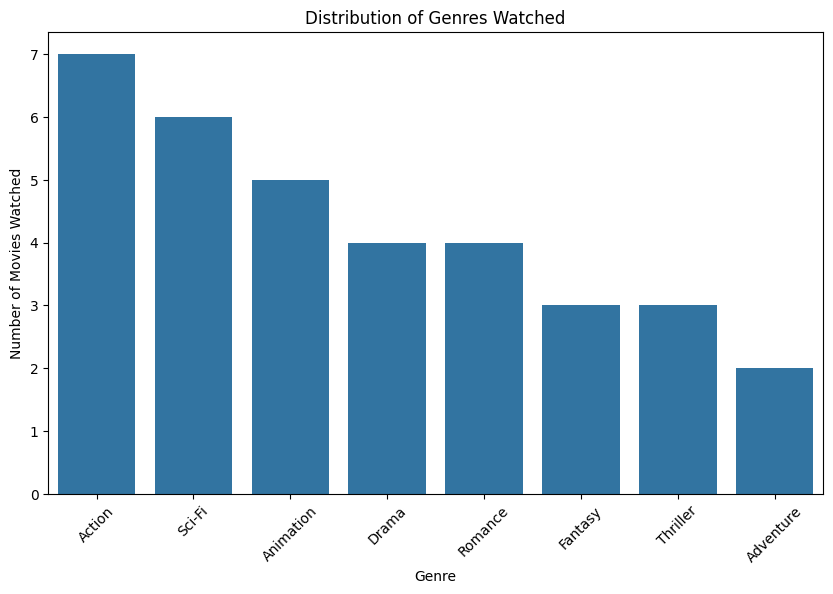

In [31]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=history_df,
    x="genre",
    order=history_df["genre"].value_counts().index
)

plt.title("Distribution of Genres Watched")
plt.xlabel("Genre")
plt.ylabel("Number of Movies Watched")
plt.xticks(rotation=45)

plt.show()

Pie chart of genres watched - The below is a Pie Chart of one users preferences

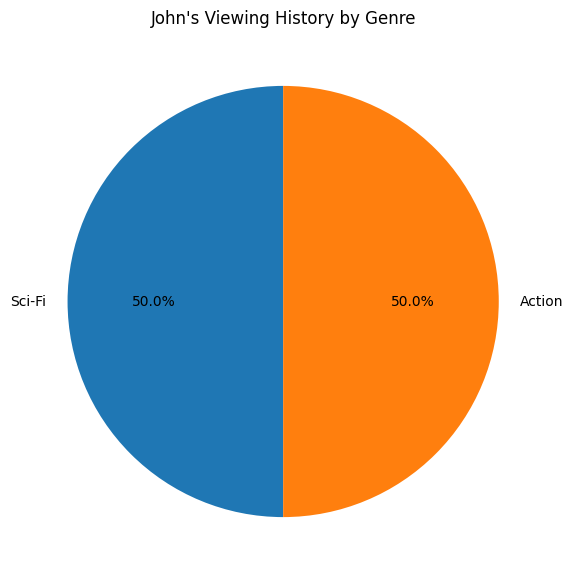

In [32]:
selected_user = "John"

user_history = history_df[
    history_df["user"] == selected_user
]

genre_distribution = user_history["genre"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    genre_distribution.values,
    labels=genre_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(f"{selected_user}'s Viewing History by Genre")

plt.show()

### Line Plot of John's Ratings for July

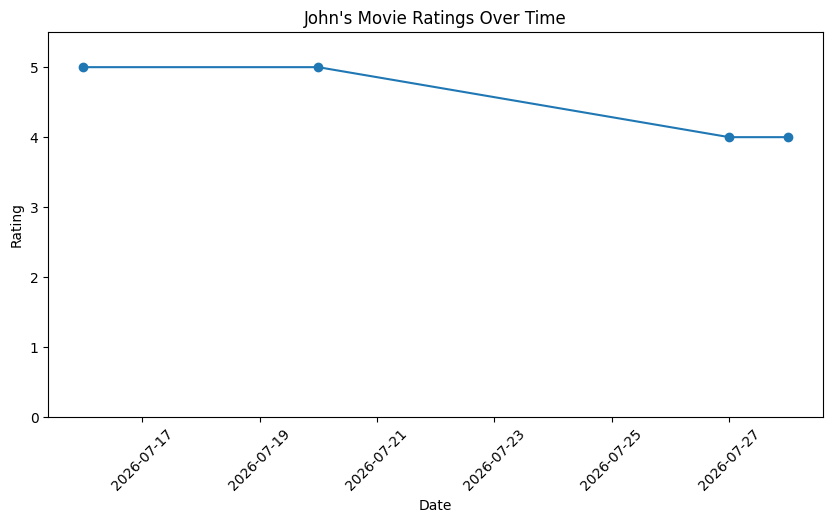

In [33]:
selected_user = "John"

user_history = history_df[
    history_df["user"] == selected_user
].sort_values("watch_date")

plt.figure(figsize=(10, 5))

plt.plot(
    user_history["watch_date"],
    user_history["rating"],
    marker="o"
)

plt.title(f"{selected_user}'s Movie Ratings Over Time")
plt.xlabel("Date")
plt.ylabel("Rating")
plt.ylim(0, 5.5)

plt.xticks(rotation=45)

plt.show()

Bar chart of average rating by genre

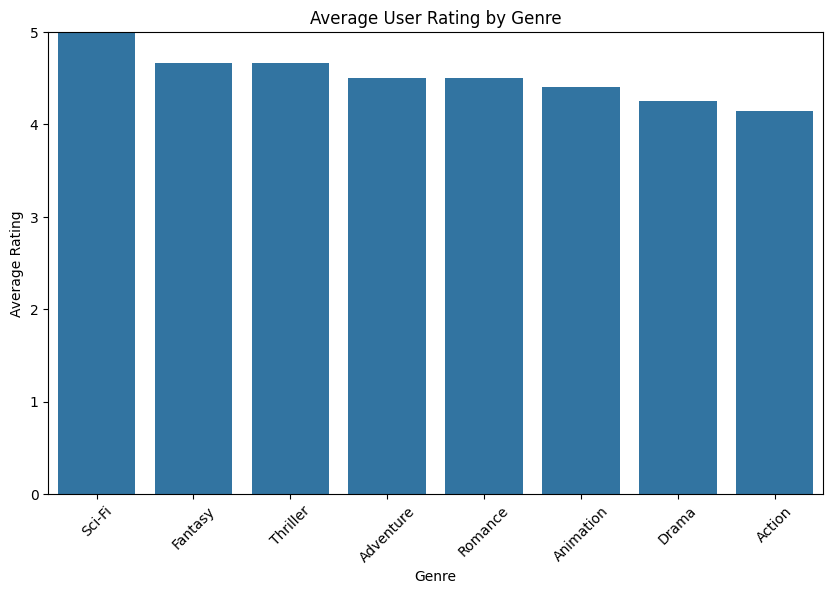

In [34]:
average_genre_rating = (
    history_df
    .groupby("genre")["rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=average_genre_rating.index,
    y=average_genre_rating.values
)

plt.title("Average User Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.ylim(0, 5)

plt.xticks(rotation=45)

plt.show()

Heatmap of overlapping user interests

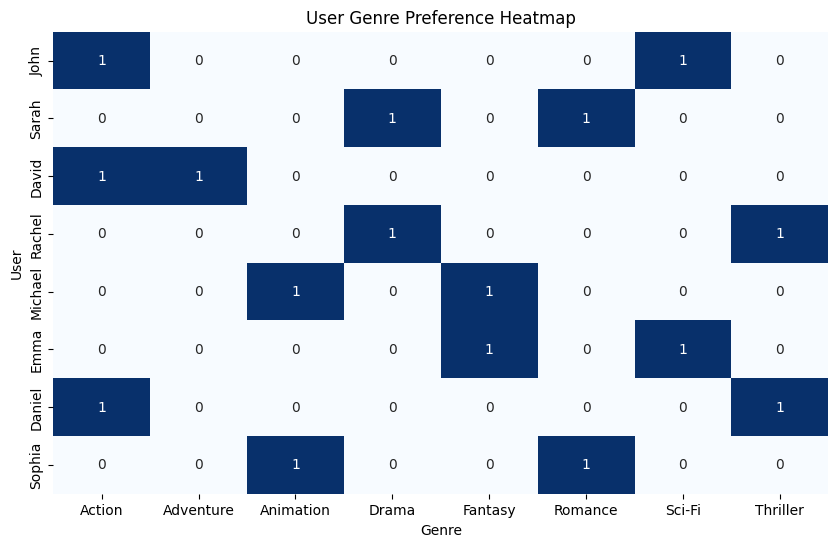

In [35]:
genre_heatmap = genre_df.set_index("name").drop(
    columns="cluster"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    genre_heatmap,
    annot=True,
    cmap="Blues",
    cbar=False
)

plt.title("User Genre Preference Heatmap")
plt.xlabel("Genre")
plt.ylabel("User")

plt.show()

Visualizing user clusters - this helps us show the number of users in each rating group

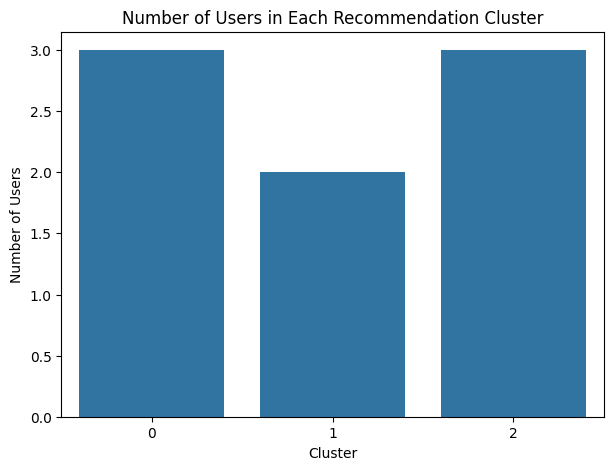

In [36]:
cluster_counts = genre_df["cluster"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Users in Each Recommendation Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Users")

plt.show()

## Object-Oriented Recommendation System

The recommendation engine was also implemented using object-oriented programming.

The `MovieRecommender` class encapsulates movie data and user information and provides reusable methods for generating personalized recommendations.

In [37]:
class MovieRecommender:

    def __init__(self, movies, users):
        self.movies = movies
        self.users = users

    def find_user(self, user_name):

        for user in self.users:
            if user["name"] == user_name:
                return user

        return None

    def recommend(self, user_name, n=3):

        user = self.find_user(user_name)

        if user is None:
            return "User not found."

        preferences = user["preferences"]

        watched = [
            movie["movie"]
            for movie in user["watch_history"]
        ]

        recommendations = self.movies[
            self.movies["genre"].isin(preferences)
            & ~self.movies["title"].isin(watched)
        ]

        recommendations = recommendations.sort_values(
            "average_rating",
            ascending=False
        )

        return recommendations.head(n)

    def personalized_message(self, user_name):

        recommendations = self.recommend(user_name)

        if isinstance(recommendations, str):
            print(recommendations)
            return

        print(f"Personalized recommendations for {user_name}:\n")

        for _, movie in recommendations.iterrows():

            print(
                f"You may enjoy {movie['title']} "
                f"because it matches your interest in "
                f"{movie['genre']} movies."
            )

In [38]:
movie_ai = MovieRecommender(
    movies_df,
    users
)

In [39]:
movie_ai.recommend("Rachel")

,movie_id,title,genre,director,year,average_rating
8,9,The Godfather,Drama,Francis Ford Coppola,1972,4.9
20,21,The Silence of the Lambs,Thriller,Jonathan Demme,1991,4.6


In [40]:
movie_ai.personalized_message("Rachel")

Personalized recommendations for Rachel:

You may enjoy The Godfather because it matches your interest in Drama movies.
You may enjoy The Silence of the Lambs because it matches your interest in Thriller movies.


Interactive Demo:  This is a demo of the actual recommendation engine

In [42]:
print("Welcome to MovieMatch AI!")
print()

print("Available users:")
for user in users:
    print("-", user["name"])

print()

user_name = input(
    "Enter a user name to receive recommendations: "
)

print()

movie_ai.personalized_message(user_name)

Welcome to MovieMatch AI!

Available users:
- John
- Sarah
- David
- Rachel
- Michael
- Emma
- Daniel
- Sophia

Enter a user name to receive recommendations: Michael

Personalized recommendations for Michael:

You may enjoy The Lord of the Rings because it matches your interest in Fantasy movies.


## Key Findings

The analysis revealed several patterns in the movie-viewing data.

1. Users showed clear preferences for specific movie genres, allowing content-based filtering to generate personalized recommendations.  For example John prefered sci-fi and action related movies.

2. The tool successfully excluded previously watched movies and ranked new movies according to genre preference and average rating.

3. Pearson correlation provides a method for measuring similarities between users based on shared movie ratings. The Pearson correlation coefficient indicated a perfect positive relationship between John and Daniel's ratings of shared movies. This means that they showed the same rating pattern for the movies they both watched.

4. Feature engineering converted categorical genre preferences into numerical variables that could be analyzed using machine-learning techniques.

5. K-means clustering successfully divided users into groups based on similar genre preferences. These clusters can be used to recommend movies enjoyed by users with similar interests.

6. The visualizations revealed differences in genre popularity and average ratings and made individual viewing behavior easier to understand.

Overall, the project demonstrates how Python, Pandas, NumPy, SciPy, and visualization libraries can be combined to simulate a personalized movie recommendation platform.

## Conclusion

MovieMatch AI demonstrates how data analysis and basic machine-learning concepts can be used to create a personalized recommendation system.

The project began by creating synthetic user profiles containing ages, genre preferences, and viewing histories. Pandas was then used to organize and analyze the data, while NumPy supported numerical operations and data simulation.

The recommendation engine used content-based filtering to match users with movies from their preferred genres while excluding movies they had already watched. Movie ratings were then used to rank the recommendations.

SciPy expanded the system by introducing Pearson correlation for comparing user rating behavior and k-means clustering for grouping users with similar genre preferences. These techniques demonstrate how recommendation systems can move beyond simple filtering and use similarities between users to improve personalization.

Finally, Matplotlib and Seaborn were used to visualize genre preferences, ratings over time, average genre ratings, and user clusters.

Although this project uses simulated data, the same concepts could be applied to larger real-world datasets from streaming services such as Netflix and Amazon Prime to create more advanced recommendation systems.